In [2]:
!pip install pandas matplotlib

In [16]:
import pandas as pd

In [17]:
import sqlite3

In [18]:
import matplotlib.pyplot as plt

In [19]:
import pandas as pd
df = pd.read_csv("student_performance.csv")

In [20]:
print("========== DATASET PREVIEW ==========")
df.head()


========== DATASET PREVIEW ==========


,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023
3,1004,Sneha Reddy,20,Female,Mechanical,2,70,80,75,48,95,Hyderabad,2023
4,1005,Arjun Nair,19,Male,Computer Science,2,92,88,81,95,90,Kochi,2023


In [21]:
import sqlite3
conn = sqlite3.connect("students.db")

In [22]:
df.to_sql("students", conn, if_exists="replace", index=False)

30

In [23]:
print("\nDatabase created successfully!")


Database created successfully!


NameError: name 'chart1' is not defined

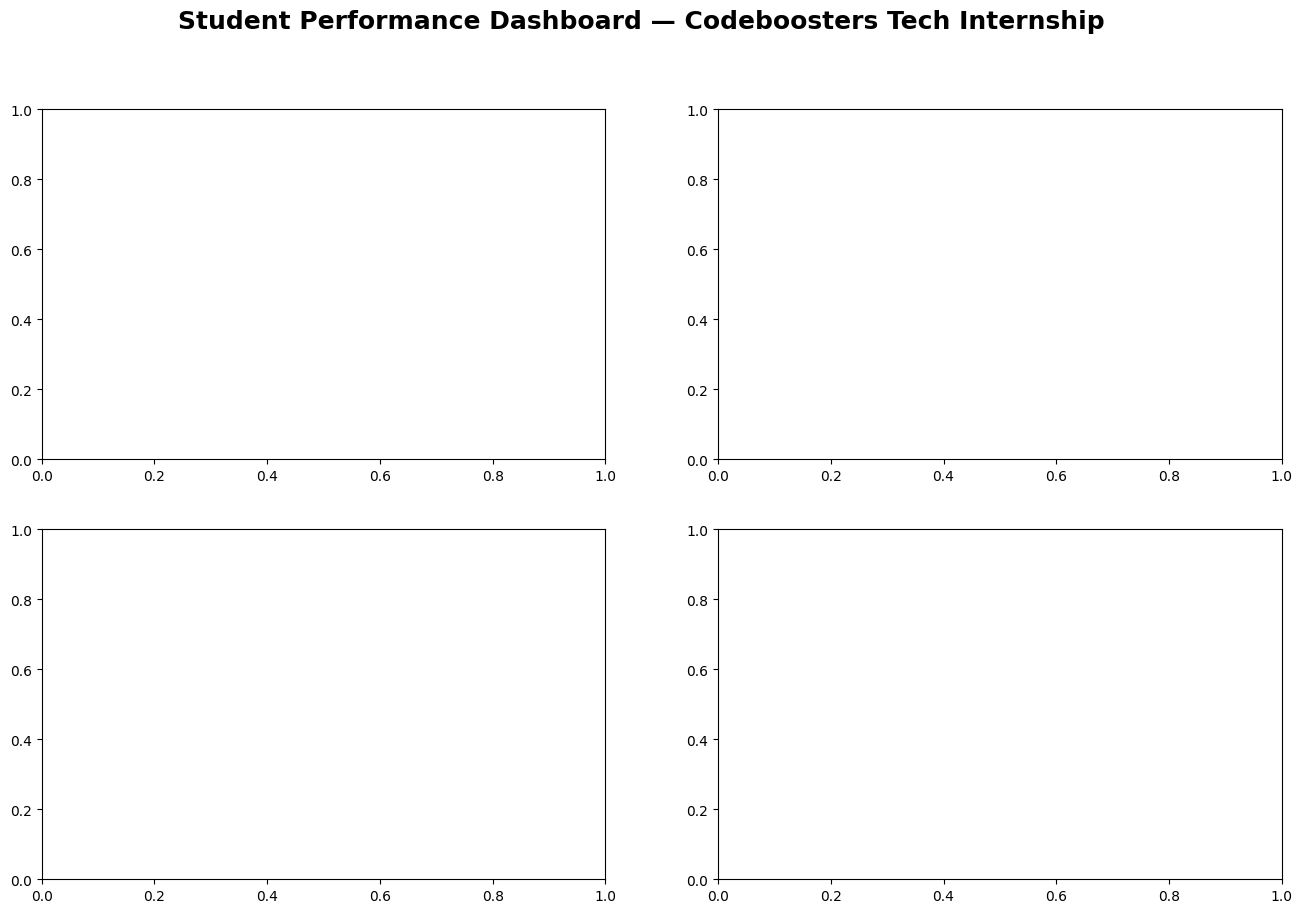

In [24]:
import matplotlib.pyplot as plt

# If you are in a Jupyter Notebook, uncomment the line below:
# %matplotlib inline

# 1. Initialize the 2x2 grid properly
fig, axs = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(
    "Student Performance Dashboard — Codeboosters Tech Internship",
    fontsize=18,
    fontweight='bold'
)

# --- Subplot [0,0]: Math Scores ---
axs[0,0].bar(chart1['department'], chart1['avg_math_score'])
axs[0,0].set_title("Avg Math Score by Department")
axs[0,0].set_ylabel("Average Score")

for i, v in enumerate(chart1['avg_math_score']):
    axs[0,0].text(i, v + 1, str(v), ha='center', fontweight='bold')

# --- Subplot [0,1]: Student Count (Duplicate removed) ---
axs[0,1].pie(chart2['student_count'], labels=chart2['department'], autopct='%1.0f%%')
axs[0,1].set_title("Students per Department")

# --- Subplot [1,0]: Top Students ---
axs[1,0].barh(chart3['name'], chart3['total_score'])
axs[1,0].invert_yaxis()
axs[1,0].set_title("Top 8 Students — Total Score")
axs[1,0].set_xlabel("Total Score")

for i, v in enumerate(chart3['total_score']):
    axs[1,0].text(v + 2, i, str(v), va='center')

# --- Subplot [1,1]: Attendance ---
axs[1,1].bar(chart4['gender'], chart4['avg_attendance'])
axs[1,1].set_title("Avg Attendance by Gender")
axs[1,1].set_ylabel("Attendance %")

for i, v in enumerate(chart4['avg_attendance']):
    axs[1,1].text(i, v + 1, f"{v}%", ha='center', fontweight='bold')

# 2. Adjust layout and force display
plt.tight_layout()
plt.show()

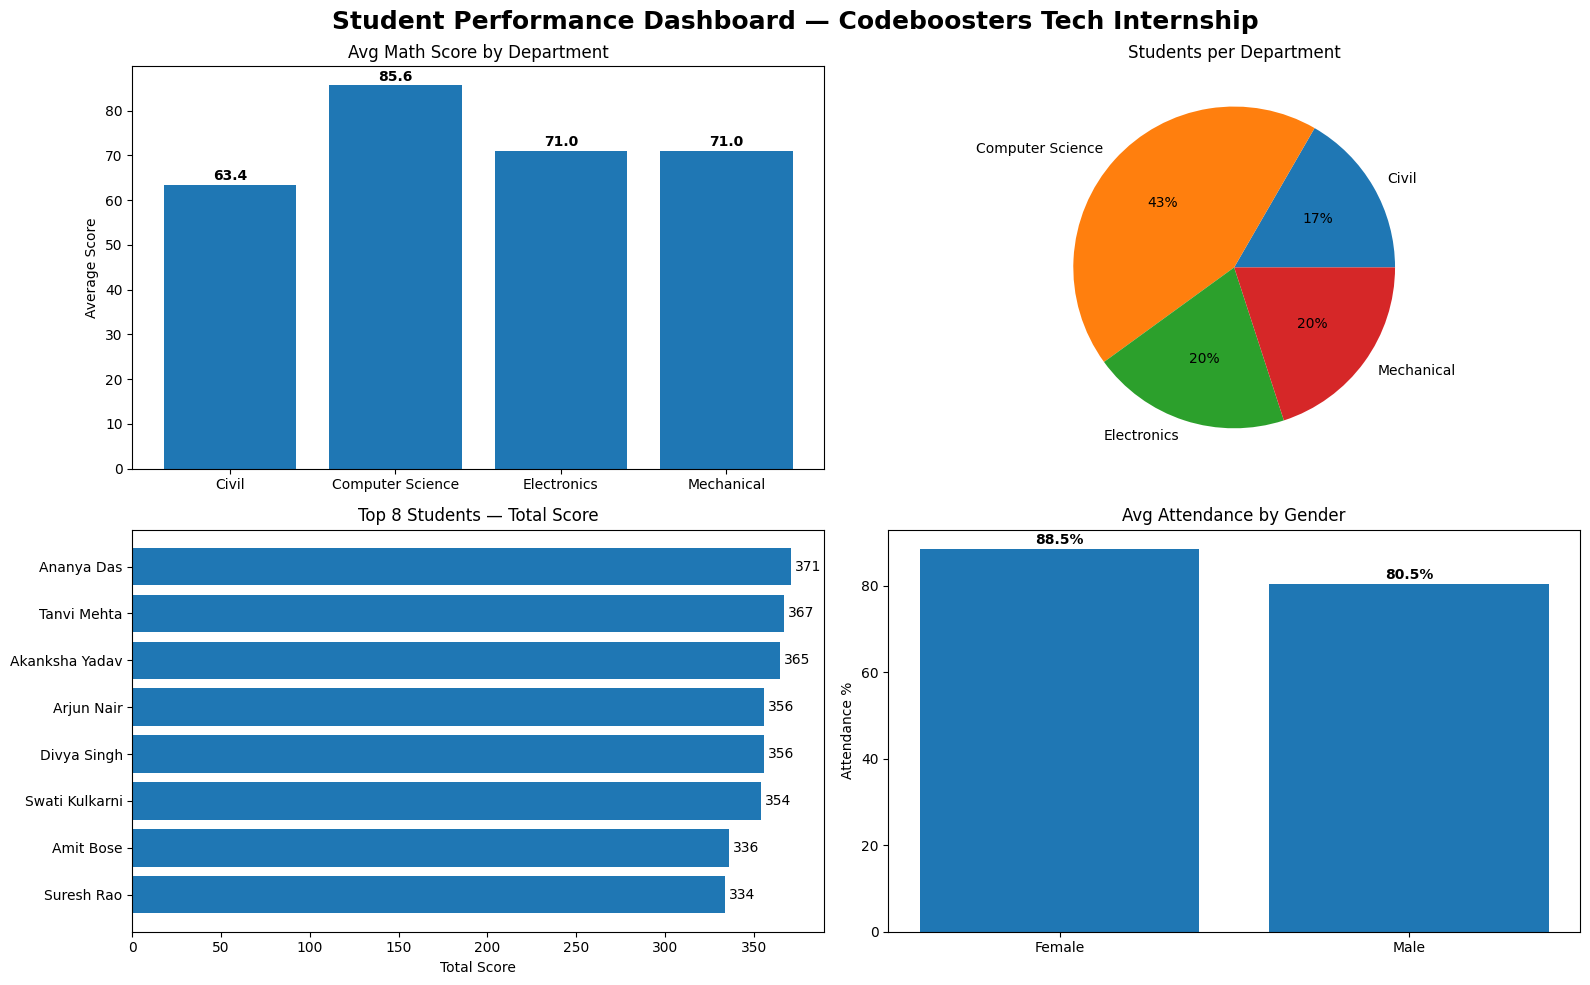

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('student_performance.csv')

# Calculate total_score before generating chart3
df['total_score'] = df['math_score'] + df['science_score'] + df['english_score'] + df['programming_score']

chart1 = df.groupby('department')['math_score'].mean().reset_index()
chart1.columns = ['department', 'avg_math_score']

chart2 = df.groupby('department')['student_id'].count().reset_index()
chart2.columns = ['department', 'student_count']

chart3 = df.nlargest(8, 'total_score')[['name', 'total_score']]

chart4 = df.groupby('gender')['attendance_percentage'].mean().reset_index()
chart4.columns = ['gender', 'avg_attendance']

fig, axs = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(
    "Student Performance Dashboard — Codeboosters Tech Internship",
    fontsize=18,
    fontweight='bold'
)

axs[0,0].bar(chart1['department'], chart1['avg_math_score'])
axs[0,0].set_title("Avg Math Score by Department")
axs[0,0].set_ylabel("Average Score")
for i, v in enumerate(chart1['avg_math_score']):
    axs[0,0].text(i, v + 1, f"{v:.1f}", ha='center', fontweight='bold')

axs[0,1].pie(chart2['student_count'], labels=chart2['department'], autopct='%1.0f%%')
axs[0,1].set_title("Students per Department")

axs[1,0].barh(chart3['name'], chart3['total_score'])
axs[1,0].invert_yaxis()
axs[1,0].set_title("Top 8 Students — Total Score")
axs[1,0].set_xlabel("Total Score")
for i, v in enumerate(chart3['total_score']):
    axs[1,0].text(v + 2, i, str(v), va='center')

axs[1,1].bar(chart4['gender'], chart4['avg_attendance'])
axs[1,1].set_title("Avg Attendance by Gender")
axs[1,1].set_ylabel("Attendance %")
for i, v in enumerate(chart4['avg_attendance']):
    axs[1,1].text(i, v + 1, f"{v:.1f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [27]:
print("\n\n========== PRACTICE QUESTIONS ==========")




========== PRACTICE QUESTIONS ==========


In [28]:
print("\nQ1. Average programming score for female students:")


Q1. Average programming score for female students:


In [35]:
q1 = """
SELECT ROUND(AVG(programming_score),2) AS avg_programming_score
FROM students
WHERE gender='Female'
"""

ans1 = pd.read_sql_query(q1, conn)

print(ans1)

   avg_programming_score
0                   70.2


In [36]:
print("\nQ2. Difference between WHERE and HAVING")


Q2. Difference between WHERE and HAVING


In [37]:

print("""
WHERE:
- Filters rows BEFORE grouping.

Example:
SELECT * FROM students
WHERE department='Computer Science';

HAVING:
- Filters grouped data AFTER GROUP BY.

Example:
SELECT department, AVG(total_score)
FROM students
GROUP BY department
HAVING AVG(total_score) > 300;
""")


WHERE:
- Filters rows BEFORE grouping.

Example:
SELECT * FROM students
WHERE department='Computer Science';

HAVING:
- Filters grouped data AFTER GROUP BY.

Example:
SELECT department, AVG(total_score)
FROM students
GROUP BY department
HAVING AVG(total_score) > 300;



In [38]:
print("\nQ3. Departments where average attendance > 85%")


Q3. Departments where average attendance > 85%


In [39]:
q3 = """
SELECT department,
ROUND(AVG(attendance_percentage),2) AS avg_attendance
FROM students
GROUP BY department
HAVING AVG(attendance_percentage) > 85
"""

ans3 = pd.read_sql_query(q3, conn)

print(ans3)

         department  avg_attendance
0  Computer Science           90.69


In [40]:
print("\nQ4. About pd.read_sql_query()")


Q4. About pd.read_sql_query()


In [41]:
print("""
pd.read_sql_query():
- Executes SQL query
- Returns the result as a Pandas DataFrame

Required arguments:
1. SQL query
2. Database connection object
""")


pd.read_sql_query():
- Executes SQL query
- Returns the result as a Pandas DataFrame

Required arguments:
1. SQL query
2. Database connection object



In [42]:
print("\nQ5. Query for Average PROGRAMMING score chart")



Q5. Query for Average PROGRAMMING score chart


In [43]:
q5 = """
SELECT department,
ROUND(AVG(programming_score),2) AS avg_programming_score
FROM students
GROUP BY department
"""

ans5 = pd.read_sql_query(q5, conn)

print(ans5)

         department  avg_programming_score
0             Civil                  40.60
1  Computer Science                  89.23
2       Electronics                  61.50
3        Mechanical                  49.33


In [44]:
conn.close()